# Laboratorio 8 - Auditoria de Sistemas

**Relatorio para entrega em PDF**  
Disciplina: Gestao de Sistemas de Informacao (GSI)  
Alunos: Lucas Garcia e Luis Augusto  
Data da aula: 30/04  
Prazo informado: 07/05


## 1. Objetivo do laboratorio

Auditar a base `log_vendas.csv` da empresa TechStore S.A. para identificar falhas de preenchimento, inconsistencias financeiras e duplicidades de transacao. O notebook tambem registra evidencias de execucao, exibe o grafico exigido pelo roteiro e apresenta uma recomendacao gerencial para a TI.

## 2. Preparacao do ambiente

O roteiro solicita o uso de `pandas` e `matplotlib`. Neste relatorio, os scripts foram organizados de forma separada e o notebook importa essas rotinas para manter o codigo-fonte textual e reutilizavel.

In [11]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

POSSIVEIS_DIRS = [Path.cwd(), Path.cwd() / "GSI" / "lab8"]
BASE_DIR = next(path for path in POSSIVEIS_DIRS if (path / "log_vendas.csv").exists())
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from auditoria_vendas import (
    carregar_base,
    executar_auditoria,
    gerar_relatorio_gerencial,
    identificar_duplicidades,
    identificar_falhas_negativos,
    identificar_falhas_nulos,
    identificar_valores_invalidos,
    montar_resumo_complementar,
    montar_resumo_principal,
)

CSV_PATH = BASE_DIR / "log_vendas.csv"
OUT_DIR = BASE_DIR / "saidas"
CSV_PATH

WindowsPath('d:/Users/2023122760328/Desktop/SIIFES-IV/GSI/lab8/log_vendas.csv')

## 3. Carga e entendimento da base

Primeiro carregamos a base original e criamos a coluna `valor_numerico`, usada para testar negatividade e identificar valores textuais invalidos.

In [12]:
df = carregar_base(CSV_PATH)
print(f"Total de registros: {len(df)}")
print(f"Colunas: {list(df.columns)}")
df.head(10)

Total de registros: 300
Colunas: ['id_transacao', 'cliente', 'valor', 'metodo_pagamento', 'valor_numerico']


,id_transacao,cliente,valor,metodo_pagamento,valor_numerico
0,101,NaN,abc,NaN,NaN
1,102,Renata Dias,-96.64,Cartao,-96.64
2,103,Ana Paula,abc,Pix,NaN
3,104,Juliana Martins,NaN,Pix,NaN
4,105,Rafael Costa,abc,Dinheiro,NaN
5,106,Camila Ferreira,-377.07,NaN,-377.07
6,107,NaN,NaN,NaN,NaN
7,108,NaN,NaN,Cartao,NaN
8,109,Felipe Batista,-462.75,Boleto,-462.75
9,110,Maria Oliveira,erro,Boleto,NaN


## 4. Validacoes exigidas pelo roteiro

As tres regras principais do laboratorio sao: valor nulo, valor negativo e duplicidade de `id_transacao`.

In [13]:
falhas_nulos = identificar_falhas_nulos(df)
falhas_negativos = identificar_falhas_negativos(df)
falhas_duplicados = identificar_duplicidades(df)
resumo_principal = montar_resumo_principal(df)
resumo_principal

,categoria,quantidade
0,Nulos,68
1,Negativos,49
2,Duplicados,0


In [14]:
print("Amostra - valor nulo")
display(falhas_nulos.head())

print("Amostra - valor negativo")
display(falhas_negativos.head())

print("Amostra - IDs duplicados")
if falhas_duplicados.empty:
    print("Nenhum ID duplicado foi encontrado nesta base.")
else:
    display(falhas_duplicados.head())

Amostra - valor nulo


,id_transacao,cliente,valor,metodo_pagamento,valor_numerico
3,104,Juliana Martins,NaN,Pix,NaN
6,107,NaN,NaN,NaN,NaN
7,108,NaN,NaN,Cartao,NaN
11,112,Rodrigo Nunes,NaN,Crypto,NaN
12,113,NaN,NaN,Boleto,NaN


Amostra - valor negativo


,id_transacao,cliente,valor,metodo_pagamento,valor_numerico
1,102,Renata Dias,-96.64,Cartao,-96.64
5,106,Camila Ferreira,-377.07,NaN,-377.07
8,109,Felipe Batista,-462.75,Boleto,-462.75
17,118,Fernanda Souza,-32.85,Boleto,-32.85
21,122,Rodrigo Nunes,-386.94,NaN,-386.94


Amostra - IDs duplicados
Nenhum ID duplicado foi encontrado nesta base.


## 5. Grafico consolidado da auditoria

A execucao abaixo salva o grafico principal em `saidas/grafico_auditoria.png` e organiza os arquivos auxiliares da auditoria.

Grafico salvo em: d:\Users\2023122760328\Desktop\SIIFES-IV\GSI\lab8\saidas\grafico_auditoria.png


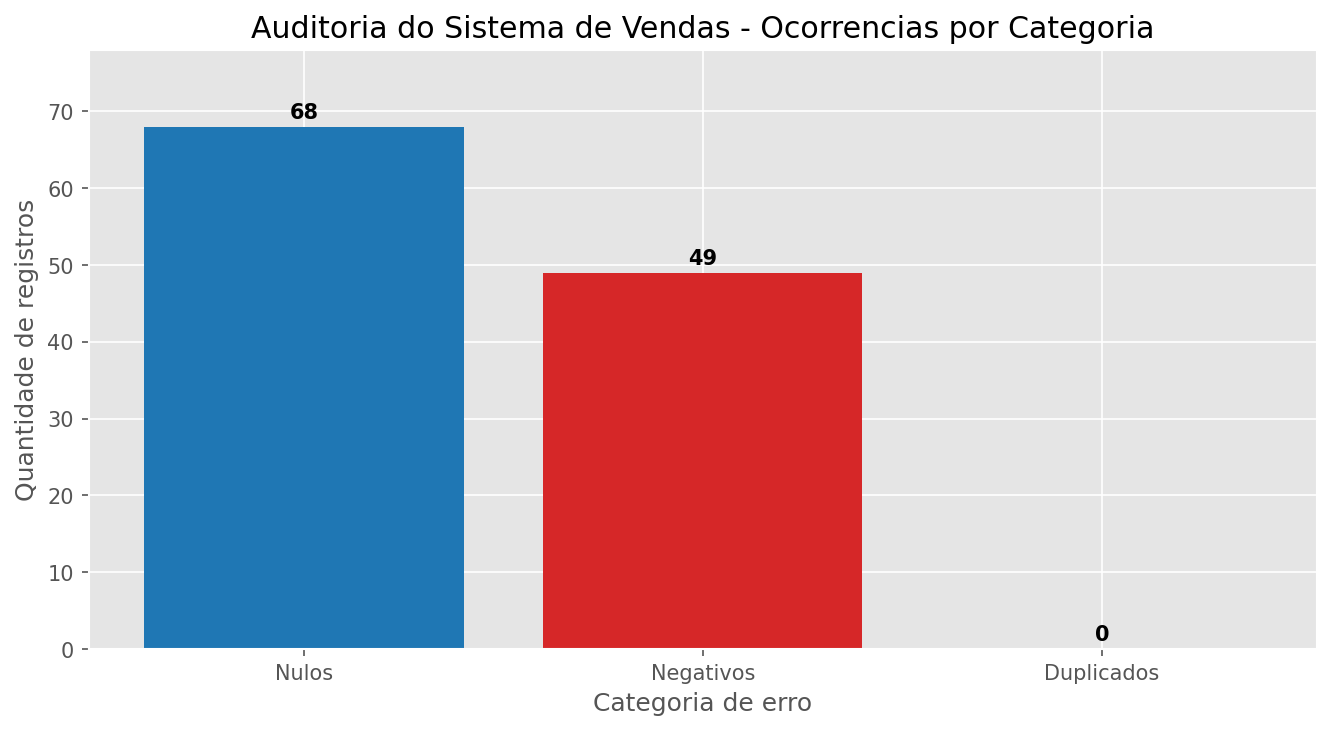

In [15]:
resultado = executar_auditoria(CSV_PATH, OUT_DIR)
print(f"Grafico salvo em: {resultado['grafico']}")
Image(filename=str(resultado['grafico']))

## 6. Analise complementar

Embora o roteiro foque em nulos, negativos e duplicados, a base tambem apresenta valores textuais invalidos em `valor` (por exemplo `abc` e `erro`) e ausencia de campos obrigatorios. Esses achados fortalecem a justificativa para novos controles no sistema.

In [16]:
resumo_complementar = montar_resumo_complementar(df)
valores_invalidos = identificar_valores_invalidos(df)
display(resumo_complementar)

print("Amostra - valores invalidos no campo valor")
display(valores_invalidos.head())

,categoria,quantidade
0,Valor invalido (texto),99
1,Cliente ausente,51
2,Metodo ausente,61


Amostra - valores invalidos no campo valor


,id_transacao,cliente,valor,metodo_pagamento,valor_numerico
0,101,NaN,abc,NaN,NaN
2,103,Ana Paula,abc,Pix,NaN
4,105,Rafael Costa,abc,Dinheiro,NaN
9,110,Maria Oliveira,erro,Boleto,NaN
10,111,NaN,abc,Dinheiro,NaN


## 7. Codigo-fonte desenvolvido

O professor solicitou que o codigo-fonte aparecesse de forma textual. As celulas abaixo carregam o conteudo dos scripts em formato legivel para exportacao no PDF.

In [17]:
def mostrar_codigo_fonte(nome_arquivo: str) -> None:
    caminho = BASE_DIR / nome_arquivo
    codigo = caminho.read_text(encoding="utf-8")
    display(Markdown(f"### Codigo-fonte: `{nome_arquivo}`"))
    display(Markdown(f"```python\n{codigo}\n```"))

for arquivo in ["auditoria_vendas.py", "test_auditoria_vendas.py"]:
    mostrar_codigo_fonte(arquivo)

### Codigo-fonte: `auditoria_vendas.py`

```python
"""Laboratorio 8 - Auditoria de Sistemas.

Script principal para auditar a base ``log_vendas.csv`` e gerar evidencias
textuais e graficas para o relatorio em notebook/PDF.
"""

from __future__ import annotations

import os
from pathlib import Path


BASE_DIR = Path(__file__).resolve().parent
os.environ.setdefault("MPLCONFIGDIR", str(BASE_DIR / ".matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd


ARQUIVO_CSV = BASE_DIR / "log_vendas.csv"
PASTA_SAIDA = BASE_DIR / "saidas"


def carregar_base(caminho_csv: Path) -> pd.DataFrame:
    """Carrega a base original e adiciona a coluna numerica derivada."""
    df = pd.read_csv(caminho_csv)
    df["valor_numerico"] = pd.to_numeric(df["valor"], errors="coerce")
    return df


def identificar_falhas_nulos(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna registros cujo campo ``valor`` esta vazio."""
    return df[df["valor"].isna()].copy()


def identificar_falhas_negativos(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna registros com valor monetario menor que zero."""
    return df[df["valor_numerico"] < 0].copy()


def identificar_duplicidades(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna transacoes com o mesmo ID repetido."""
    mascara = df["id_transacao"].duplicated(keep=False)
    return df[mascara].sort_values("id_transacao").copy()


def identificar_valores_invalidos(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna valores nao vazios que nao puderam ser convertidos em numero."""
    mascara = df["valor"].notna() & df["valor_numerico"].isna()
    return df[mascara].copy()


def identificar_campos_obrigatorios_ausentes(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna registros com cliente ou metodo de pagamento ausentes."""
    mascara = df["cliente"].isna() | df["metodo_pagamento"].isna()
    return df[mascara].copy()


def montar_resumo_principal(df: pd.DataFrame) -> pd.DataFrame:
    """Monta o resumo exigido pelo roteiro do laboratorio."""
    resumo = {
        "Nulos": len(identificar_falhas_nulos(df)),
        "Negativos": len(identificar_falhas_negativos(df)),
        "Duplicados": len(identificar_duplicidades(df)),
    }
    return pd.DataFrame(
        {"categoria": list(resumo.keys()), "quantidade": list(resumo.values())}
    )


def montar_resumo_complementar(df: pd.DataFrame) -> pd.DataFrame:
    """Consolida problemas adicionais encontrados na base."""
    resumo = {
        "Valor invalido (texto)": len(identificar_valores_invalidos(df)),
        "Cliente ausente": int(df["cliente"].isna().sum()),
        "Metodo ausente": int(df["metodo_pagamento"].isna().sum()),
    }
    return pd.DataFrame(
        {"categoria": list(resumo.keys()), "quantidade": list(resumo.values())}
    )


def gerar_grafico(resumo: pd.DataFrame, caminho_saida: Path) -> Path:
    """Gera o grafico de barras principal da auditoria."""
    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=(9, 5))
    barras = ax.bar(
        resumo["categoria"],
        resumo["quantidade"],
        color=["#1f77b4", "#d62728", "#2ca02c"],
    )
    ax.set_title("Auditoria do Sistema de Vendas - Ocorrencias por Categoria")
    ax.set_xlabel("Categoria de erro")
    ax.set_ylabel("Quantidade de registros")
    ax.set_ylim(0, max(resumo["quantidade"].max(), 1) + 10)

    for barra in barras:
        altura = int(barra.get_height())
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.6,
            str(altura),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    fig.tight_layout()
    caminho_saida.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(caminho_saida, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return caminho_saida


def salvar_evidencias(df: pd.DataFrame, pasta_saida: Path) -> dict[str, Path]:
    """Salva os recortes usados na auditoria para consulta posterior."""
    pasta_saida.mkdir(parents=True, exist_ok=True)

    arquivos = {
        "falhas_nulos": pasta_saida / "falhas_valor_nulo.csv",
        "falhas_negativos": pasta_saida / "falhas_valor_negativo.csv",
        "falhas_duplicados": pasta_saida / "falhas_id_duplicado.csv",
        "falhas_invalidos": pasta_saida / "falhas_valor_invalido.csv",
        "falhas_campos_obrigatorios": pasta_saida / "falhas_campos_obrigatorios.csv",
        "resumo_principal": pasta_saida / "resumo_principal.csv",
        "resumo_complementar": pasta_saida / "resumo_complementar.csv",
    }

    identificar_falhas_nulos(df).to_csv(arquivos["falhas_nulos"], index=False)
    identificar_falhas_negativos(df).to_csv(arquivos["falhas_negativos"], index=False)
    identificar_duplicidades(df).to_csv(arquivos["falhas_duplicados"], index=False)
    identificar_valores_invalidos(df).to_csv(arquivos["falhas_invalidos"], index=False)
    identificar_campos_obrigatorios_ausentes(df).to_csv(
        arquivos["falhas_campos_obrigatorios"], index=False
    )
    montar_resumo_principal(df).to_csv(arquivos["resumo_principal"], index=False)
    montar_resumo_complementar(df).to_csv(arquivos["resumo_complementar"], index=False)

    return arquivos


def gerar_relatorio_gerencial(
    resumo_principal: pd.DataFrame, resumo_complementar: pd.DataFrame
) -> str:
    """Produz um parecer curto para ser usado na conclusao do notebook."""
    problema_principal = resumo_principal.sort_values(
        "quantidade", ascending=False
    ).iloc[0]
    problema_complementar = resumo_complementar.sort_values(
        "quantidade", ascending=False
    ).iloc[0]

    return (
        "O problema mais critico do sistema, considerando as validacoes exigidas "
        f"no roteiro, sao os registros com valor nulo ({int(problema_principal['quantidade'])} "
        f"ocorrencias). Como achado complementar, a base tambem possui "
        f"{int(problema_complementar['quantidade'])} ocorrencias de "
        f"{problema_complementar['categoria'].lower()}, o que indica ausencia de "
        "validacao de entrada no cadastro de vendas. A recomendacao para a TI e "
        "implantar validacoes obrigatorias no momento da gravacao, bloquear "
        "valores negativos e textos no campo valor, registrar logs de erro e criar "
        "rotinas periodicas de auditoria automatizada."
    )


def executar_auditoria(caminho_csv: Path = ARQUIVO_CSV, pasta_saida: Path = PASTA_SAIDA) -> dict:
    """Executa o fluxo completo da auditoria e devolve os artefatos principais."""
    df = carregar_base(caminho_csv)
    resumo_principal = montar_resumo_principal(df)
    resumo_complementar = montar_resumo_complementar(df)
    grafico = gerar_grafico(resumo_principal, pasta_saida / "grafico_auditoria.png")
    arquivos = salvar_evidencias(df, pasta_saida)

    return {
        "df": df,
        "resumo_principal": resumo_principal,
        "resumo_complementar": resumo_complementar,
        "grafico": grafico,
        "arquivos": arquivos,
        "relatorio_gerencial": gerar_relatorio_gerencial(
            resumo_principal, resumo_complementar
        ),
    }


def main() -> None:
    """Ponto de entrada em linha de comando."""
    resultado = executar_auditoria()
    df = resultado["df"]
    resumo_principal = resultado["resumo_principal"]
    resumo_complementar = resultado["resumo_complementar"]

    print("=" * 60)
    print("LABORATORIO 8 - AUDITORIA DE SISTEMAS")
    print("=" * 60)
    print(f"Arquivo analisado: {ARQUIVO_CSV.name}")
    print(f"Total de registros: {len(df)}")
    print()
    print("Resumo principal:")
    print(resumo_principal.to_string(index=False))
    print()
    print("Resumo complementar:")
    print(resumo_complementar.to_string(index=False))
    print()
    print("Exemplo de falhas de valor nulo:")
    print(identificar_falhas_nulos(df).head(5).to_string(index=False))
    print()
    print("Exemplo de falhas de valor negativo:")
    print(identificar_falhas_negativos(df).head(5).to_string(index=False))
    print()
    print("Exemplo de valores invalidos no campo valor:")
    print(identificar_valores_invalidos(df).head(5).to_string(index=False))
    print()
    print("Relatorio gerencial:")
    print(resultado["relatorio_gerencial"])
    print()
    print(f"Grafico salvo em: {resultado['grafico']}")
    print(f"Evidencias salvas em: {PASTA_SAIDA}")


if __name__ == "__main__":
    main()

```

### Codigo-fonte: `test_auditoria_vendas.py`

```python
"""Testes do Laboratorio 8 - Auditoria de Sistemas."""

from __future__ import annotations

import unittest
from pathlib import Path

import pandas as pd

from auditoria_vendas import (
    ARQUIVO_CSV,
    carregar_base,
    identificar_duplicidades,
    identificar_falhas_negativos,
    identificar_falhas_nulos,
    identificar_valores_invalidos,
    montar_resumo_principal,
)


class AuditoriaVendasTestCase(unittest.TestCase):
    """Valida as regras centrais do script de auditoria."""

    def test_contagens_da_base_real(self) -> None:
        df = carregar_base(ARQUIVO_CSV)

        self.assertEqual(len(df), 300)
        self.assertEqual(len(identificar_falhas_nulos(df)), 68)
        self.assertEqual(len(identificar_falhas_negativos(df)), 49)
        self.assertEqual(len(identificar_duplicidades(df)), 0)
        self.assertEqual(len(identificar_valores_invalidos(df)), 99)

    def test_duplicidades_em_base_controlada(self) -> None:
        df = pd.DataFrame(
            [
                {"id_transacao": 1, "cliente": "Ana", "valor": "10", "metodo_pagamento": "Pix"},
                {"id_transacao": 1, "cliente": "Bruno", "valor": "20", "metodo_pagamento": "Cartao"},
                {"id_transacao": 2, "cliente": "Carla", "valor": "-5", "metodo_pagamento": "Boleto"},
            ]
        )
        df["valor_numerico"] = pd.to_numeric(df["valor"], errors="coerce")

        duplicados = identificar_duplicidades(df)
        negativos = identificar_falhas_negativos(df)

        self.assertEqual(duplicados["id_transacao"].tolist(), [1, 1])
        self.assertEqual(negativos["id_transacao"].tolist(), [2])

    def test_resumo_principal_tem_categorias_esperadas(self) -> None:
        df = carregar_base(Path(ARQUIVO_CSV))
        resumo = montar_resumo_principal(df)

        self.assertEqual(resumo["categoria"].tolist(), ["Nulos", "Negativos", "Duplicados"])
        self.assertEqual(resumo["quantidade"].tolist(), [68, 49, 0])


if __name__ == "__main__":
    unittest.main()

```

## 8. Evidencias de execucao

As proximas celulas executam o script principal e a bateria de testes. Essa saida pode ser mantida no PDF final como evidencia objetiva da execucao.

In [21]:
comando_script = [sys.executable, str(BASE_DIR / "auditoria_vendas.py")]
resultado_script = subprocess.run(comando_script, capture_output=True, text=True, check=True)
print(resultado_script.stdout)

LABORATORIO 8 - AUDITORIA DE SISTEMAS
Arquivo analisado: log_vendas.csv
Total de registros: 300

Resumo principal:
 categoria  quantidade
     Nulos          68
 Negativos          49
Duplicados           0

Resumo complementar:
             categoria  quantidade
Valor invalido (texto)          99
       Cliente ausente          51
        Metodo ausente          61

Exemplo de falhas de valor nulo:
 id_transacao         cliente valor metodo_pagamento  valor_numerico
          104 Juliana Martins   NaN              Pix             NaN
          107             NaN   NaN              NaN             NaN
          108             NaN   NaN           Cartao             NaN
          112   Rodrigo Nunes   NaN           Crypto             NaN
          113             NaN   NaN           Boleto             NaN

Exemplo de falhas de valor negativo:
 id_transacao         cliente   valor metodo_pagamento  valor_numerico
          102     Renata Dias  -96.64           Cartao          -96.64
   

In [19]:
comando_testes = [sys.executable, "-m", "unittest", "-v", str(BASE_DIR / "test_auditoria_vendas.py")]
resultado_testes = subprocess.run(comando_testes, capture_output=True, text=True, check=True)
print(resultado_testes.stdout)
if resultado_testes.stderr:
    print(resultado_testes.stderr)


test_contagens_da_base_real (test_auditoria_vendas.AuditoriaVendasTestCase.test_contagens_da_base_real) ... ok
test_duplicidades_em_base_controlada (test_auditoria_vendas.AuditoriaVendasTestCase.test_duplicidades_em_base_controlada) ... ok
test_resumo_principal_tem_categorias_esperadas (test_auditoria_vendas.AuditoriaVendasTestCase.test_resumo_principal_tem_categorias_esperadas) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.010s

OK



## 9. Relatorio gerencial

Com base nas categorias obrigatorias do grafico, o problema mais critico e a quantidade de registros com `valor` nulo. Como agravante, a base possui um volume ainda maior de valores textuais invalidos, mostrando que o sistema nao valida adequadamente o preenchimento numerico no momento da entrada.

In [20]:
print(gerar_relatorio_gerencial(resumo_principal, resumo_complementar))

O problema mais critico do sistema, considerando as validacoes exigidas no roteiro, sao os registros com valor nulo (68 ocorrencias). Como achado complementar, a base tambem possui 99 ocorrencias de valor invalido (texto), o que indica ausencia de validacao de entrada no cadastro de vendas. A recomendacao para a TI e implantar validacoes obrigatorias no momento da gravacao, bloquear valores negativos e textos no campo valor, registrar logs de erro e criar rotinas periodicas de auditoria automatizada.


## 10. Conclusao

O notebook atende aos itens do roteiro: apresenta os scripts em formato textual, executa as validacoes pedidas, gera o grafico de barras e registra evidencias de execucao. Para a entrega em PDF, basta exportar este notebook ou o HTML gerado a partir dele, preservando o grafico e as saidas das celulas.